# Phase 2 Growth Analysis

### load packages, read in data, etc.

In [2]:
library(lme4) #for linear mixed effects model
library(readr) #to read in data
library(emmeans) #for post hocs
library(esquisse) #interface for building plots
library(dplyr) #for data wrangling
library(nlme) #for linear mixed effects model
library(car) #for the Levene test
library(ggplot2) #for graphs
library(plotrix) #for standard error
library(performance) #model testing
library(lmtest) #another option than levene test for variance

In [3]:
getwd()
setwd("/Users/sophiemontague/Desktop/MontagueORCC_repo/MontagueORCC")

[1] "/Users/sophiemontague/Desktop/MontagueORCC_repo/MontagueORCC"

In [4]:
options(contrasts = c("contr.sum","contr.poly")) #could also be contr.treatment for unequal groups sum
getOption("contrasts") 

[1] "contr.sum"  "contr.poly"

In [5]:
Growth_Data_forR <- read_csv("Oyster_Weight_Data/growth_phase2.1_weightsSKM.csv", 
                             col_types = cols(Phase_1_temp = col_factor(), 
                                              Phase_1_DO =col_factor(), 
                                              Phase_2.1_temp =col_factor(), 
                                              Phase_2.1_DO=col_factor(), 
                                              Phase_1_rep =col_factor(), 
                                              Phase_2_rep =col_factor(),
                                              Ratio_tissue_shell_mg = col_double(),
                                              Phase1_Phase2_rep = col_factor(),
                                              Phase_1_treat = col_factor(),
                                              Phase_2_treat = col_factor(),
                                              Phase_2_rep_R = col_factor(),
                                              Phase_1_rep_R = col_factor()))

### Filter to exclude dead oysters

In [6]:
Growth_Data_forR_full <- Growth_Data_forR %>%
  filter(Exclude_all != "Y" | is.na(Exclude_all)) %>%
  mutate(prop_tissue_growth = Actual_tissue_growth_mg / Actual_tissue_pre_mg,
    prop_shell_growth = Actual_shell_growth_mg / Actual_shell_pre_mg, 
    tissuegrowthratio = Actual_tissue_post_mg/Actual_tissue_pre_mg,
    shellgrowthratio = Actual_shell_post_mg/Actual_shell_pre_mg,
    log_shell_growth_mg = log(Actual_shell_growth_mg),
    whole_growth_mg = Dry_weight_post - Dry_weight_pre,
    meat_yield_post = Actual_tissue_post_mg/Dry_weight_post,
    shell_yield_post = Actual_shell_post_mg/Dry_weight_post)

# 1. Effect of phase 2, TISSUE

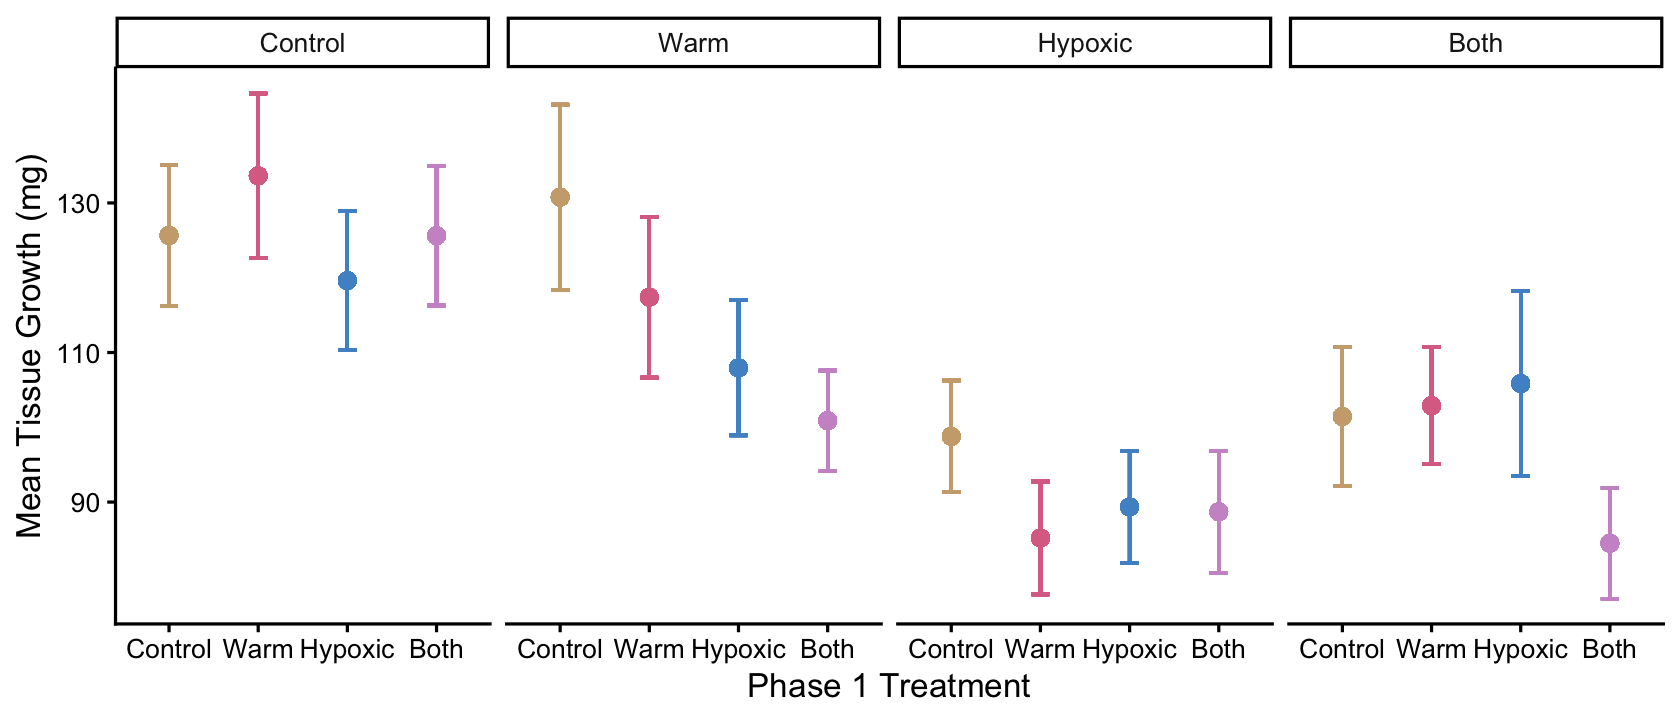

In [7]:
#format for jupyter
options(repr.plot.width = 14, repr.plot.height = 6)

#all, TISSUE
summary_stats_t <- Growth_Data_forR_full %>%
  group_by(Phase_1_treat, Phase_2_treat) %>%
  mutate(
    mean_growth = mean(Actual_tissue_growth_mg, na.rm = TRUE),
    se_growth = std.error(Actual_tissue_growth_mg, na.rm = TRUE))

  #reorder Phase_1_treat and Phase_2_treat
  summary_stats_t$Phase_1_treat <- factor(summary_stats_t$Phase_1_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))
  summary_stats_t$Phase_2_treat <- factor(summary_stats_t$Phase_2_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))
  
  #plot with mean and SD, TISSUE
  ggplot(summary_stats_t, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
    geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
    geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                  width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
    theme_classic(base_size = 20) +
    guides(color = "none") + # Remove legend for color
    facet_wrap(vars(Phase_2_treat), 
               labeller = as_labeller(c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")), 
               scales = "fixed", nrow = 1) + # Facet by Phase_2_treat
    scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
    labs(x = "Phase 1 Treatment", y = "Mean Tissue Growth (mg)") +
    scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
    theme(legend.position = "none") # Remove legend

## statistical analysis

In [8]:
##tissue growth (mg)
    #removing covariate because AIC lower without
m1 <- lmer(Actual_tissue_growth_mg~ Phase_1_DO*Phase_1_temp*Phase_2.1_temp*Phase_2.1_DO+
             (1|Phase_2_rep_R)+(1|Phase_1_rep_R)+
             (1|Phase_2_rep_R:Phase_1_DO)+(1|Phase_2_rep_R:Phase_1_temp)+(1|Phase_2_rep_R:Phase_1_DO:Phase_1_temp), data = Growth_Data_forR_full, REML=TRUE)

aov_tab <- Anova(m1, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

boundary (singular) fit: see help('isSingular')



,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),441.59053212,1,21.93222,0.0000
Phase_1_DO,2.44742392,1,15.08262,0.1385
Phase_1_temp,0.89788152,1,13.48828,0.3600
Phase_2.1_temp,0.03007135,1,20.00076,0.8641
Phase_2.1_DO,6.82698293,1,20.00131,0.0167
Phase_1_DO:Phase_1_temp,0.01145252,1,13.49223,0.9164
Phase_1_DO:Phase_2.1_temp,0.82502839,1,19.99873,0.3745
Phase_1_temp:Phase_2.1_temp,1.20349421,1,19.98562,0.2857
Phase_1_DO:Phase_2.1_DO,0.73924872,1,20.00106,0.4001


Warning message in leveneTest.default(y = y, group = group, ...):
“group coerced to factor.”


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,15,1.609486,0.06472139
,1101,NA,NA


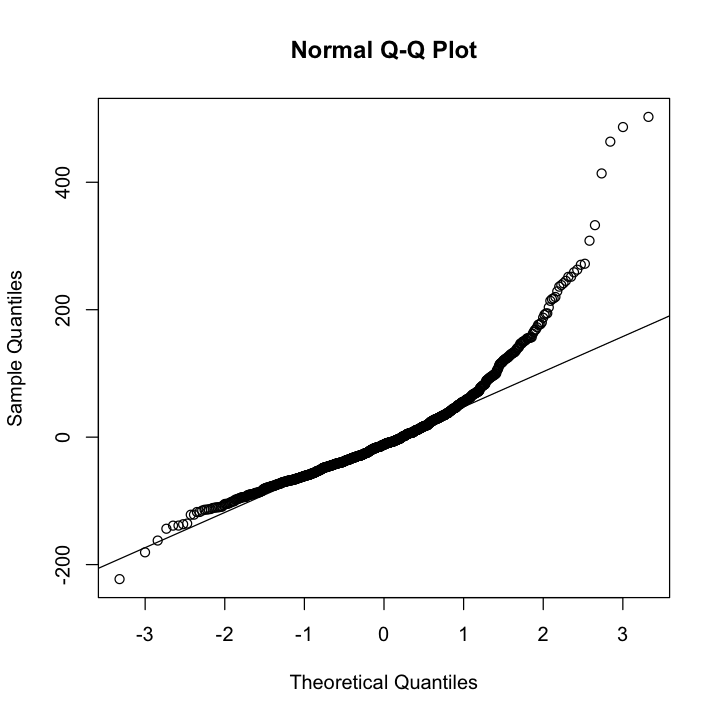

In [106]:
#format display for jupyter
options(repr.plot.width = 6, repr.plot.height = 6)

leveneTest(Actual_tissue_growth_mg~Phase1_Phase2_treat, Growth_Data_forR_full)
m1.e <- residuals(m1) 
qqnorm(m1.e)
qqline(m1.e)

In [109]:
#posthocs
emmeans(m1,specs = pairwise ~ Phase_2.1_DO, adjust = "none")

NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_2.1_DO emmean   SE   df lower.CL upper.CL
 Hyp            94.7 7.08 21.5       80      109
 Norm          120.2 7.07 21.4      106      135

Results are averaged over the levels of: Phase_1_DO, Phase_1_temp, Phase_2.1_temp 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

$contrasts
 contrast   estimate   SE df t.ratio p.value
 Hyp - Norm    -25.5 9.77 20  -2.613  0.0167

Results are averaged over the levels of: Phase_1_DO, Phase_1_temp, Phase_2.1_temp 
Degrees-of-freedom method: kenward-roger 


### plotting significant interactions

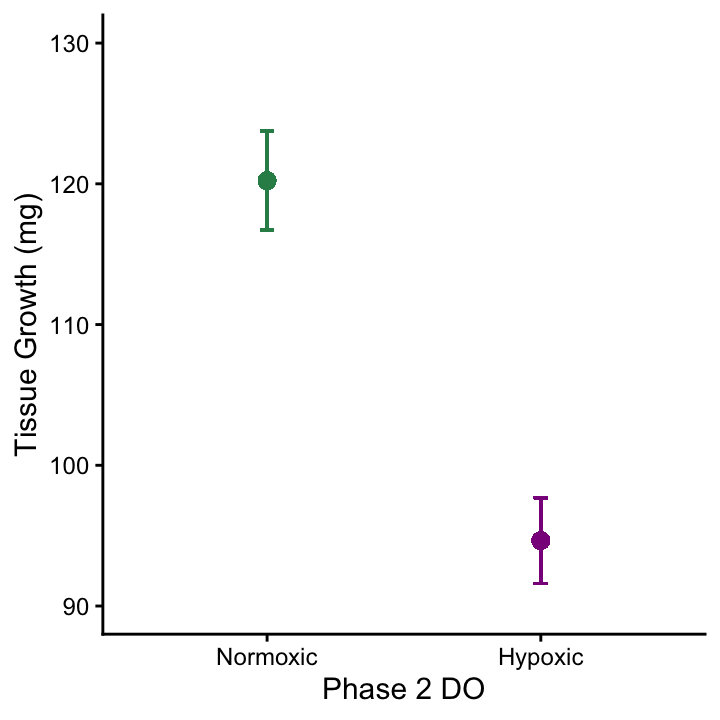

In [108]:
stats_t <- Growth_Data_forR_full %>%
  group_by(Phase_2.1_DO) %>%
  mutate(
    mean_growth = mean(Actual_tissue_growth_mg, na.rm = TRUE),
    se_growth = std.error(Actual_tissue_growth_mg, na.rm = TRUE))
#reorder
stats_t$Phase_2.1_DO <- factor(stats_t$Phase_2.1_DO, 
                               levels = c("Norm","Hyp"))
#Tissue plot with mean and SD
ggplot(stats_t, aes(x = Phase_2.1_DO, y = mean_growth, color = Phase_2.1_DO)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.05, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  guides(color = "none") + # Remove legend for color
  scale_color_manual(values = c("Hyp" = "darkmagenta", "Norm" = "seagreen")) +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Norm" = "Normoxic")) +
  labs(x = "Phase 2 DO", y = "Tissue Growth (mg)") +
  ylim(90, 130)+
  theme(legend.position = "none") # Remove legend

Oysters grew less tissue when exposed to diel cycling hypoxia (p = 0.03)

# 2. Effect of phase 2, SHELL

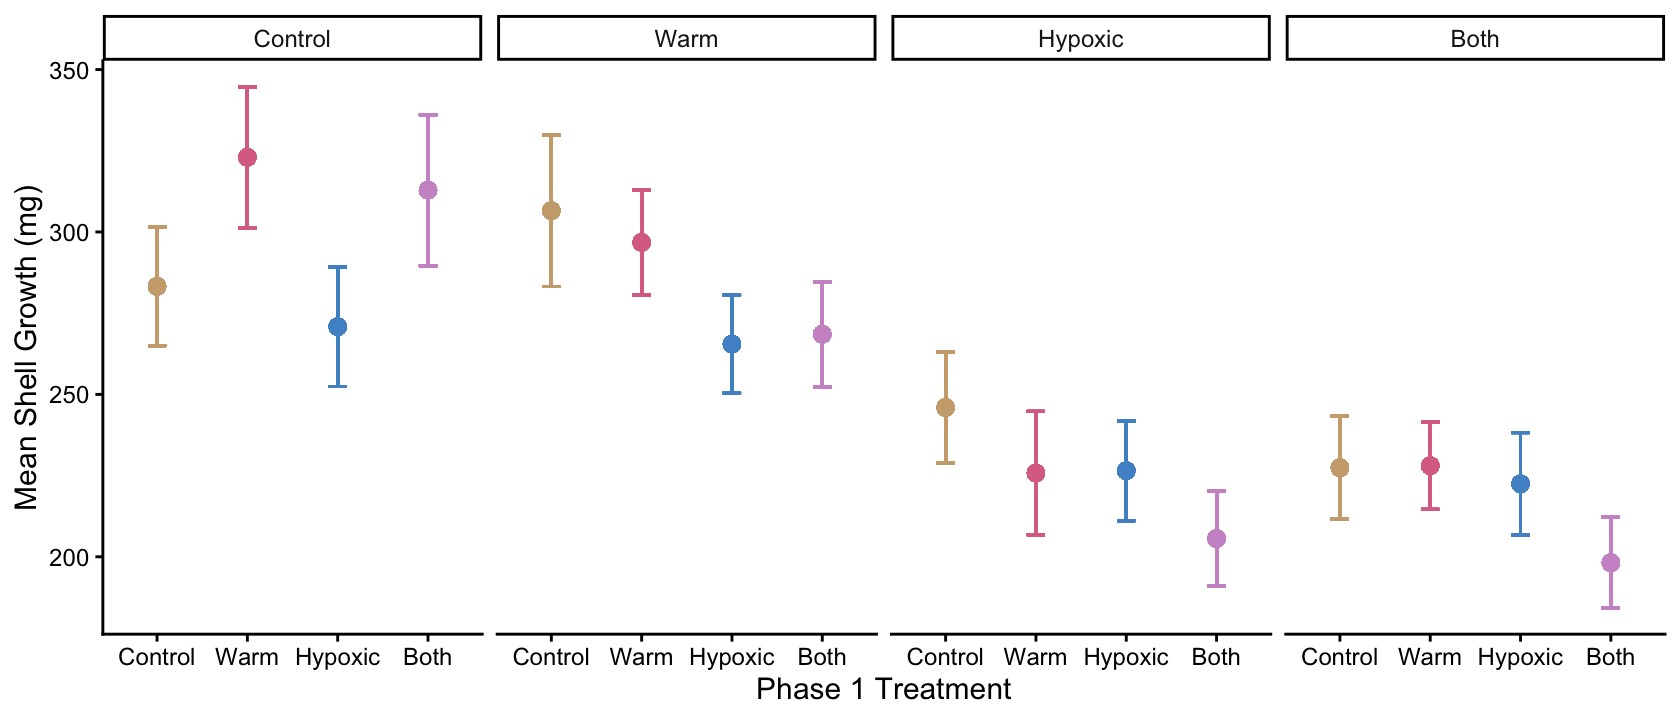

In [38]:
#format display for jupyter
options(repr.plot.width = 14, repr.plot.height = 6)

#all, SHELL
summary_stats_s <- Growth_Data_forR_full%>%
  group_by(Phase_1_treat, Phase_2_treat) %>%
  mutate(
    mean_growth = mean(Actual_shell_growth_mg, na.rm = TRUE),
    se_growth = std.error(Actual_shell_growth_mg, na.rm = TRUE))

  #reorder Phase_1_treat and Phase_2_treat
  summary_stats_s$Phase_1_treat <- factor(summary_stats_s$Phase_1_treat, 
                                        levels = c("Cont", "Warm","Hyp",  "Both"))
  summary_stats_s$Phase_2_treat <- factor(summary_stats_s$Phase_2_treat, 
                                        levels = c("Cont", "Warm","Hyp",  "Both"))
  
  #plot with mean and SD, SHELL
  ggplot(summary_stats_s, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
    geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
    geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                  width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
    theme_classic(base_size = 18) +
    guides(color = "none") + # Remove legend for color
    facet_wrap(vars(Phase_2_treat), labeller = as_labeller(c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")),
               scales = "fixed", nrow = 1) + # Facet by Phase_2_treat
    scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
    labs(x = "Phase 1 Treatment", y = "Mean Shell Growth (mg)") +
    scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
    theme(legend.position = "none") # Remove legend

## statistical analysis

In [10]:
#log, using this model for analysis
    #trying different covariates (selected by AIC)
m2 <- lmer(log_shell_growth_mg~ Phase_1_DO*Phase_1_temp*Phase_2.1_DO*Phase_2.1_temp+Actual_shell_pre_mg+
              (1|Phase_2_rep_R)+(1|Phase_1_rep_R)+
              (1|Phase_2_rep_R:Phase_1_DO)+(1|Phase_2_rep_R:Phase_1_temp)+(1|Phase_2_rep_R:Phase_1_DO:Phase_1_temp), data = Growth_Data_forR_full, REML=TRUE)

aov_tab <- Anova(m2, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

boundary (singular) fit: see help('isSingular')



,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),7.254317e+03,1,36.21981,0.0000
Phase_1_DO,1.448014e-01,1,11.00178,0.7108
Phase_1_temp,2.198995e-01,1,10.85882,0.6484
Phase_2.1_DO,8.180019e+00,1,19.97077,0.0097
Phase_2.1_temp,1.126637e-01,1,19.98772,0.7406
Actual_shell_pre_mg,4.657033e+02,1,1078.43862,0.0000
Phase_1_DO:Phase_1_temp,4.607707e+00,1,10.73609,0.0556
Phase_1_DO:Phase_2.1_DO,1.278236e+00,1,19.95737,0.2716
Phase_1_temp:Phase_2.1_DO,3.481627e+00,1,20.11898,0.0767


Warning message in leveneTest.default(y = y, group = group, ...):
“group coerced to factor.”


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,15,1.122033,0.3308683
,1101,NA,NA


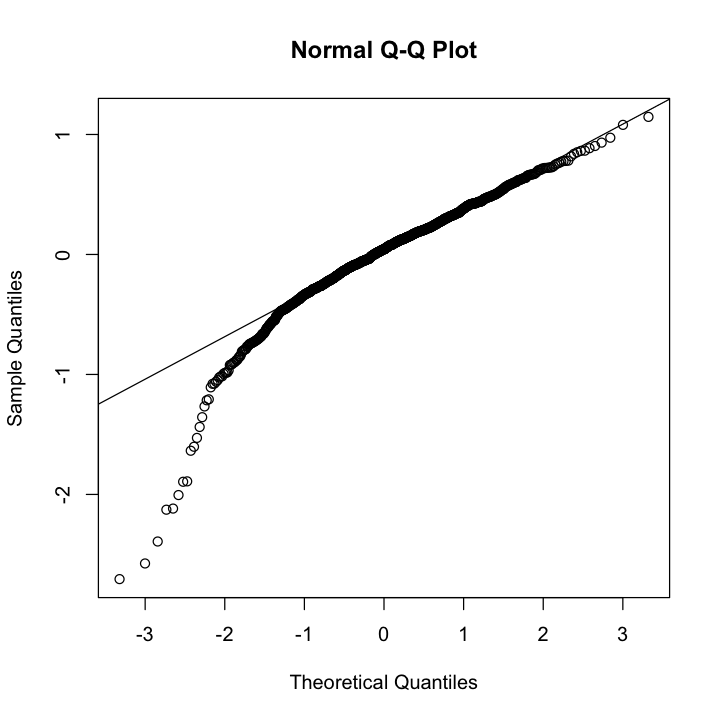

In [23]:
#format display for jupyter
options(repr.plot.width = 6, repr.plot.height = 6)

leveneTest(log_shell_growth_mg~Phase1_Phase2_treat, Growth_Data_forR_full)
m3.e <- residuals(m28)
qqnorm(m3.e)
qqline(m3.e)

Warning message in leveneTest.default(y = y, group = group, ...):
“group coerced to factor.”


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,15,1.122033,0.3308683
,1101,NA,NA


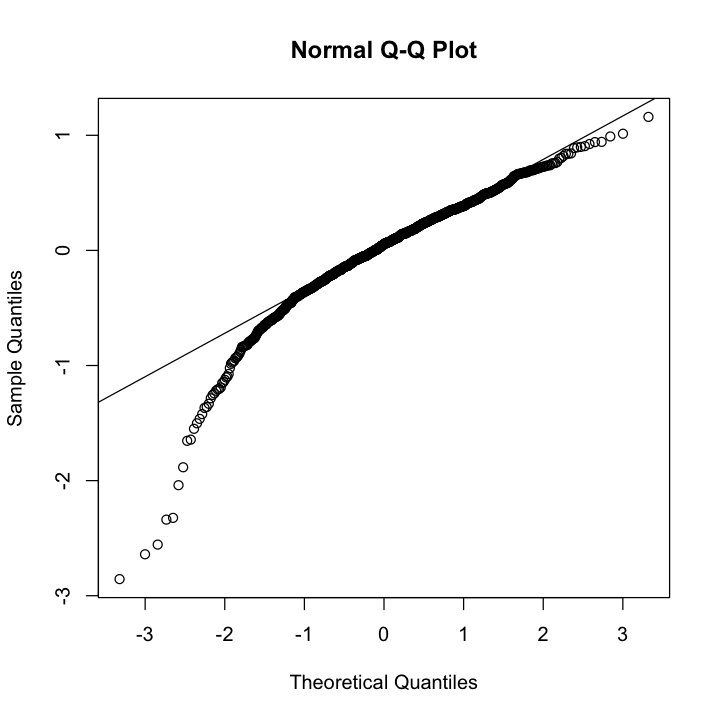

In [43]:
#format display for jupyter
options(repr.plot.width = 6, repr.plot.height = 6)

leveneTest(log_shell_growth_mg~Phase1_Phase2_treat, Growth_Data_forR_full)
m3.e <- residuals(Lm2)
qqnorm(m3.e)
qqline(m3.e)

In [14]:
emmeans(m2,specs = pairwise ~ Phase_2.1_DO, adjust = "none")
emmeans(m2,specs = pairwise ~ Phase_1_temp*Phase_2.1_DO, adjust = "none") 

NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_2.1_DO emmean     SE   df lower.CL upper.CL
 Hyp            5.23 0.0675 20.1     5.09     5.37
 Norm           5.51 0.0675 20.1     5.37     5.65

Results are averaged over the levels of: Phase_1_DO, Phase_1_temp, Phase_2.1_temp 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

$contrasts
 contrast   estimate     SE df t.ratio p.value
 Hyp - Norm   -0.273 0.0953 20  -2.860  0.0097

Results are averaged over the levels of: Phase_1_DO, Phase_1_temp, Phase_2.1_temp 
Degrees-of-freedom method: kenward-roger 


NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_1_temp Phase_2.1_DO emmean     SE   df lower.CL upper.CL
 Warm         Hyp            5.22 0.0706 23.6     5.07     5.36
 Ambient      Hyp            5.25 0.0704 23.4     5.11     5.40
 Warm         Norm           5.54 0.0705 23.6     5.39     5.69
 Ambient      Norm           5.47 0.0703 23.2     5.33     5.62

Results are averaged over the levels of: Phase_1_DO, Phase_2.1_temp 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

$contrasts
 contrast                   estimate     SE   df t.ratio p.value
 Warm Hyp - Ambient Hyp      -0.0383 0.0403 17.1  -0.951  0.3549
 Warm Hyp - Warm Norm        -0.3245 0.0994 23.5  -3.262  0.0034
 Warm Hyp - Ambient Norm     -0.2591 0.0996 23.4  -2.602  0.0158
 Ambient Hyp - Warm Norm     -0.2862 0.0996 23.5  -2.872  0.0085
 Ambient Hyp - Ambient Norm  -0.2208 0.0991 23.2  -2.228  0.0359
 Warm Norm - Ambient Norm     0.0654 0.0399 16.6   1.638  0.1202

Results are averaged over the levels of: Phase_1_DO, Phase_2.1

### plotting significant interactions

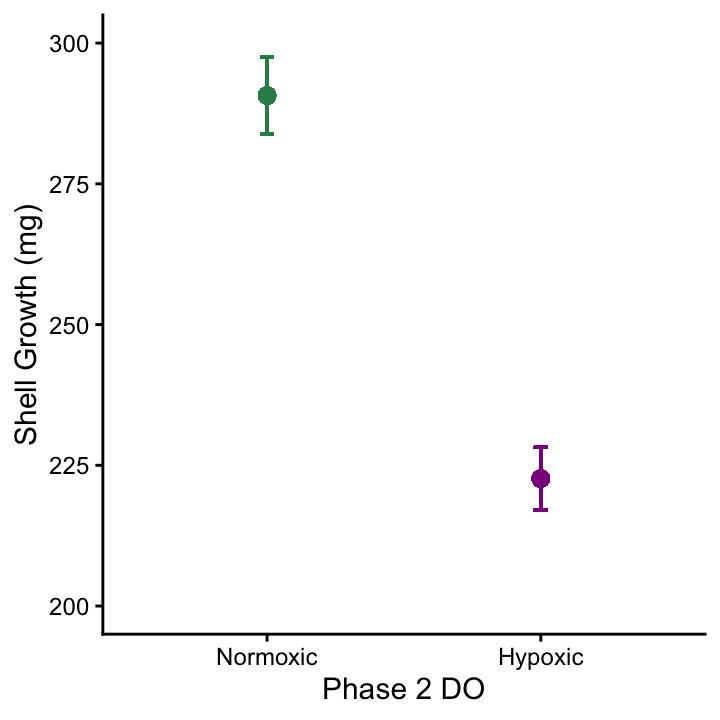

In [46]:
#shell growth and PHASE 2 DO
stats_s <- Growth_Data_forR_full %>%
  group_by(Phase_2.1_DO) %>%
  mutate(
    mean_growth = mean(Actual_shell_growth_mg, na.rm = TRUE),
    se_growth = std.error(Actual_shell_growth_mg, na.rm = TRUE))
#reorder
stats_s$Phase_2.1_DO <- factor(stats_s$Phase_2.1_DO, 
                               levels = c("Norm","Hyp"))
#Shell plot with mean and SD
ggplot(stats_s, aes(x = Phase_2.1_DO, y = mean_growth, color = Phase_2.1_DO)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.05, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  guides(color = "none") + # Remove legend for color
  scale_color_manual(values = c("Hyp" = "darkmagenta", "Norm" = "seagreen")) +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Norm" = "Normoxic")) +
  labs(x = "Phase 2 DO", y = "Shell Growth (mg)") +
  ylim(200, 300)+
  theme(legend.position = "none") # Remove legend

### Oysters grew less shell when exposed to diel cycling hypoxia (p < 0.01)

<details>
<summary>Show R code for shell growth and Phase_1_DO:Phase_1_temp graph </summary>

```r
stats_s <- Growth_Data_forR_full %>%
  group_by(Phase_1_treat) %>%
  mutate(
    mean_growth = mean(Actual_shell_growth_mg, na.rm = TRUE),
    se_growth = std.error(Actual_shell_growth_mg, na.rm = TRUE))
#reorder
stats_s$Phase_1_treat <- factor(stats_s$Phase_1_treat, 
                                levels = c("Cont", "Warm","Hyp", "Both"))
#Shell plot with mean and SD
ggplot(stats_s, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.1, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 16) +
  guides(color = "none") + # Remove legend for color
  scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
  labs(x = "Phase 1 Treatment", y = "Shell Growth in Phase 2 (mg)") +
  ylim(230,280) +
  theme(legend.position = "none") # Remove legend

(not significant with new random effect (log(tissue growth))

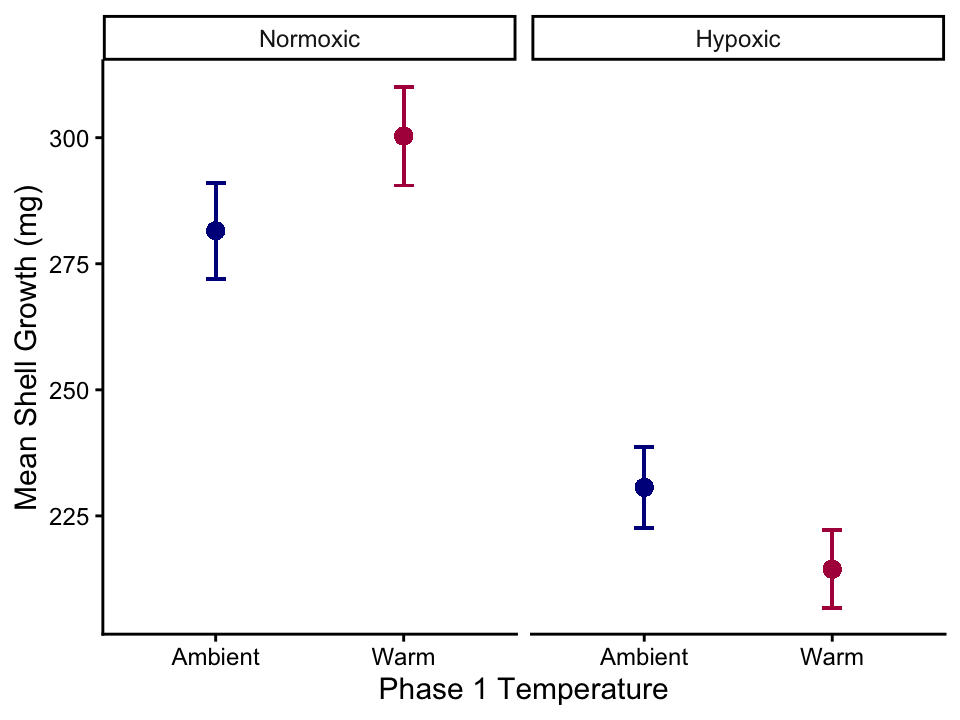

In [32]:
#format display for jupyter
options(repr.plot.width = 8, repr.plot.height = 6)

#shell growth and Phase_1_temp:Phase_2.1_DO
stats_s <- Growth_Data_forR_full %>%
  group_by(Phase_1_temp, Phase_2.1_DO) %>%
  mutate(
    mean_growth = mean(Actual_shell_growth_mg, na.rm = TRUE),
    se_growth = std.error(Actual_shell_growth_mg, na.rm = TRUE))

#reorder Phase_1_temp:Phase_2.1_DO
stats_s$Phase_1_temp <- factor(stats_s$Phase_1_temp, 
                                        levels = c("Ambient", "Warm"))
stats_s$Phase_2.1_DO <- factor(stats_s$Phase_2.1_DO, 
                                        levels = c("Norm","Hyp"))

#plot with mean and SD, SHELL
ggplot(stats_s, aes(x = Phase_1_temp, y = mean_growth, color = Phase_1_temp)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.1, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  guides(color = "none") + # Remove legend for color
  facet_wrap(vars(Phase_2.1_DO), labeller = as_labeller(c("Norm" = "Normoxic", "Hyp" = "Hypoxic")),
             scales = "fixed", nrow = 1) + # Facet by Phase_2_treat
  scale_color_manual(values = c("Warm" = "#B00149", "Ambient" = "darkblue")) +
  labs(x = "Phase 1 Temperature", y = "Mean Shell Growth (mg)") +
  scale_x_discrete(labels = c("Norm" = "Normoxic", "Hyp" = "Hypoxic")) +
  theme(legend.position = "none") # Remove legend

<details>
<summary>Make sure model outputs match raw data (but log transformed) </summary>

```r

emm <- emmeans(Lm28, ~ Phase_1_temp * Phase_2.1_DO)

emm_df <- as.data.frame(emm)

emm_df$Phase_1_temp <- factor(emm_df$Phase_1_temp, 
                                        levels = c("Ambient", "Warm"))
emm_df$Phase_2.1_DO <- factor(emm_df$Phase_2.1_DO, 
                                        levels = c("Norm","Hyp"))
ggplot(emm_df,
       aes(x = Phase_1_temp, y = emmean, color = Phase_1_temp)) +
  geom_point(size = 4) +
  geom_errorbar(
  aes(ymin = emmean - SE, ymax = emmean + SE), width = 0.1)+
  facet_wrap(~Phase_2.1_DO,
             labeller = as_labeller(c(
               "Norm" = "Normoxic",
               "Hyp" = "Hypoxic"
             )),
             nrow = 1) +
  scale_color_manual(values = c(
    "Warm" = "#B00149",
    "Ambient" = "darkblue"
  )) +
  theme_classic(base_size = 18) +
  guides(color = "none") +
  labs(
    x = "Phase 1 Temperature",
    y = "Predicted Shell Growth (mg)"
  ) +
  theme(legend.position = "none")

### Oysters exposed to either early life temperature grew less shell when exposed to hypoxia
(same story as before, oysters grew less shell in hypoxia)

# 3. Effect of phase 2, TISSUE : SHELL GROWTH

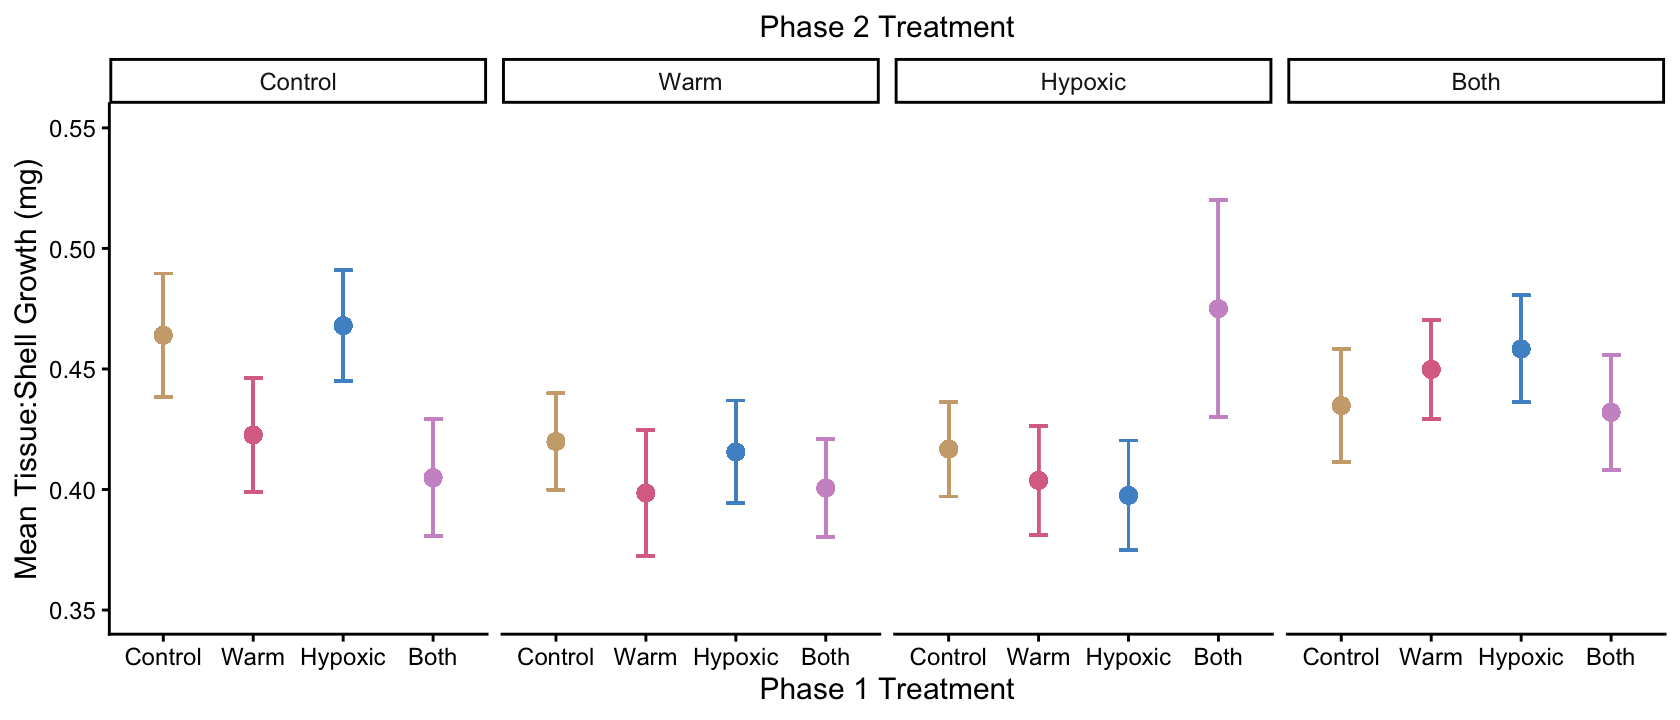

In [85]:
#all T:S
summary_stats_t_s <-Growth_Data_forR_full %>%
  group_by(Phase_1_treat, Phase_2_treat) %>%
  mutate(
    mean_growth = mean(Ratio_tissue_shell_mg, na.rm = TRUE),
    se_growth = std.error(Ratio_tissue_shell_mg, na.rm = TRUE))

  #reorder Phase_1_treat and Phase_2_treat
  summary_stats_t_s$Phase_1_treat <- factor(summary_stats_t_s$Phase_1_treat, 
                                          levels = c("Cont", "Warm","Hyp", "Both"))
  summary_stats_t_s$Phase_2_treat <- factor(summary_stats_t_s$Phase_2_treat, 
                                          levels = c("Cont", "Warm","Hyp",  "Both"))
  
  #plot with mean and SD, T:S
  ggplot(summary_stats_t_s, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
    geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
    geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                  width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
    theme_classic(base_size = 18) +
    guides(color = "none") + # Remove legend for color
    facet_wrap(vars(Phase_2_treat), 
               labeller = as_labeller(c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")), 
               scales = "fixed", nrow = 1) +
    scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
    labs(title = "Phase 2 Treatment", x = "Phase 1 Treatment", y = "Mean Tissue:Shell Growth (mg)") +
    scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
    ylim(0.35,0.55)+
    theme(
      plot.title = element_text(size = 18, hjust = 0.5))


## statistical analysis

In [72]:
m3 <- lmer(Ratio_tissue_shell_mg~ Phase_1_DO*Phase_1_temp*Phase_2.1_DO*Phase_2.1_temp+
             (1|Phase_2_rep_R)+(1|Phase_1_rep_R)+
             (1|Phase_2_rep_R:Phase_1_DO:Phase_1_temp), data = Growth_Data_forR_full, REML=TRUE)

aov_tab<-Anova(m3, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

boundary (singular) fit: see help('isSingular')



,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),7.442247e+02,1,20.79934,0.0000
Phase_1_DO,2.379589e-01,1,16.32012,0.6322
Phase_1_temp,7.558023e-01,1,16.32257,0.3972
Phase_2.1_DO,1.040554e-01,1,20.00084,0.7504
Phase_2.1_temp,3.196371e-02,1,20.00060,0.8599
Phase_1_DO:Phase_1_temp,1.336422e-01,1,16.32896,0.7194
Phase_1_DO:Phase_2.1_DO,6.719530e-01,1,59.88748,0.4156
Phase_1_temp:Phase_2.1_DO,4.438171e+00,1,59.90652,0.0393
Phase_1_DO:Phase_2.1_temp,1.782326e-01,1,59.88254,0.6744


Warning message in leveneTest.default(y = y, group = group, ...):
“group coerced to factor.”


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,15,0.8144784,0.6621946
,1101,NA,NA


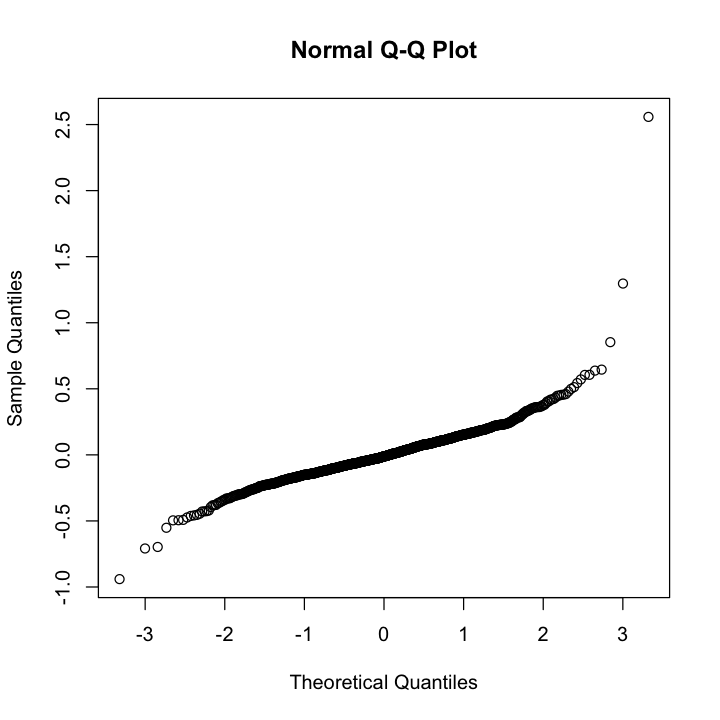

In [69]:
#format display for jupyter
options(repr.plot.width = 6, repr.plot.height = 6)

leveneTest(Ratio_tissue_shell_mg~Phase1_Phase2_treat, Growth_Data_forR_full) 
m3.e <- residuals(m3) 
qqnorm(m3.e)

In [74]:
#posthocs
options(width = 120)
emmeans(m3,specs = pairwise ~ Phase_1_temp:Phase_2.1_DO, adjust="none")
emmeans(m3,specs = pairwise ~ Phase_1_DO:Phase_1_temp:Phase_2.1_DO:Phase_2.1_temp, adjust="none")

NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_1_temp Phase_2.1_DO emmean     SE   df lower.CL upper.CL
 Warm         Hyp           0.440 0.0238 27.0    0.392    0.489
 Ambient      Hyp           0.427 0.0237 26.7    0.379    0.476
 Warm         Norm          0.406 0.0238 27.0    0.357    0.455
 Ambient      Norm          0.442 0.0236 26.4    0.393    0.490

Results are averaged over the levels of: Phase_1_DO, Phase_2.1_temp 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

$contrasts
 contrast                   estimate     SE   df t.ratio p.value
 Warm Hyp - Ambient Hyp      0.01326 0.0176 35.1   0.753  0.4565
 Warm Hyp - Warm Norm        0.03460 0.0331 26.2   1.045  0.3055
 Warm Hyp - Ambient Norm    -0.00142 0.0335 26.7  -0.042  0.9665
 Ambient Hyp - Warm Norm     0.02134 0.0336 26.9   0.636  0.5303
 Ambient Hyp - Ambient Norm -0.01467 0.0329 25.7  -0.445  0.6597
 Warm Norm - Ambient Norm   -0.03602 0.0175 34.3  -2.057  0.0473

Results are averaged over the levels of: Phase_1_DO, Phase_2.1

$emmeans
 Phase_1_DO Phase_1_temp Phase_2.1_DO Phase_2.1_temp emmean     SE   df lower.CL upper.CL
 Hyp        Warm         Hyp          Warm            0.433 0.0376 40.1    0.357    0.509
 Norm       Warm         Hyp          Warm            0.450 0.0376 40.1    0.374    0.526
 Hyp        Ambient      Hyp          Warm            0.458 0.0374 39.2    0.383    0.534
 Norm       Ambient      Hyp          Warm            0.434 0.0373 38.8    0.359    0.509
 Hyp        Warm         Norm         Warm            0.400 0.0376 40.1    0.324    0.476
 Norm       Warm         Norm         Warm            0.398 0.0374 39.2    0.322    0.473
 Hyp        Ambient      Norm         Warm            0.416 0.0372 38.4    0.340    0.491
 Norm       Ambient      Norm         Warm            0.420 0.0372 38.4    0.345    0.495
 Hyp        Warm         Hyp          Ambient         0.476 0.0375 39.6    0.401    0.552
 Norm       Warm         Hyp          Ambient         0.402 0.0375 39.6    0.327    0.478
 

### plotting significant interactions

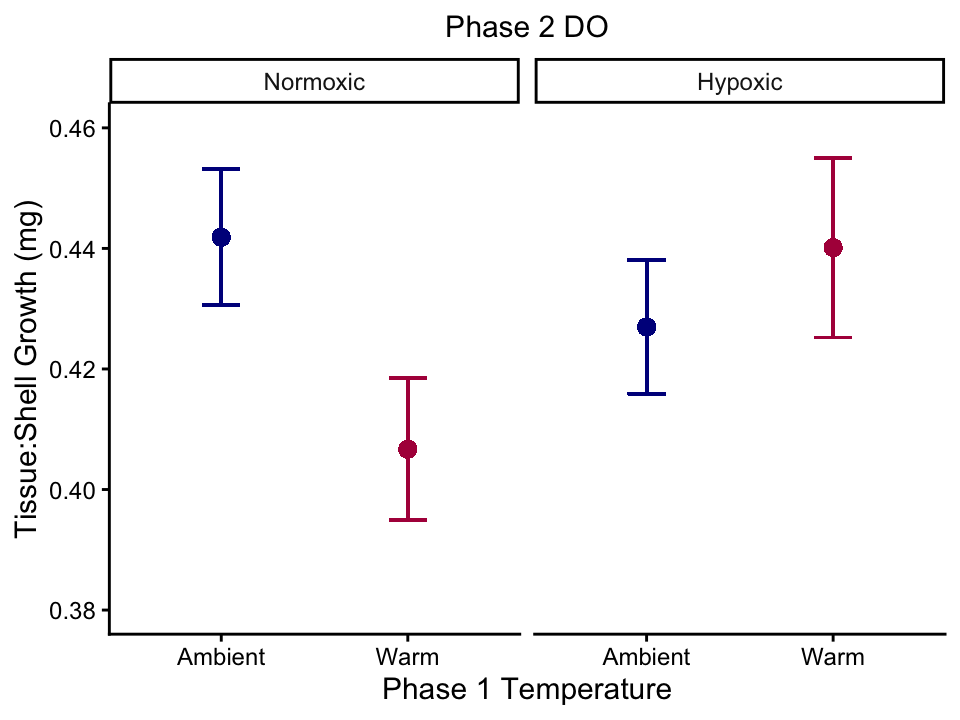

In [61]:
#format display for jupyter
options(repr.plot.width = 8, repr.plot.height = 6)

stats_ts <- Growth_Data_forR_full %>%
  group_by(Phase_1_temp, Phase_2.1_DO) %>%
  mutate(
    mean_growth = mean(Ratio_tissue_shell_mg, na.rm = TRUE),
    se_growth = std.error(Ratio_tissue_shell_mg, na.rm = TRUE))
#order
stats_ts$Phase_2.1_DO <- factor(stats_ts$Phase_2.1_DO, 
                                levels = c("Norm", "Hyp"))
stats_ts$Phase_1_temp <- factor(stats_ts$Phase_1_temp, 
                                levels = c("Ambient", "Warm"))
#Tissue:Shell plot with mean and SD
ggplot(stats_ts, aes(x = Phase_1_temp, y = mean_growth, color = Phase_1_temp)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  facet_wrap(~ Phase_2.1_DO, labeller = as_labeller(c("Hyp" = "Hypoxic", "Norm" = "Normoxic"))) +
  guides(color = "none") + # Remove legend for color
  scale_color_manual(values = c("Warm" = "#B00149", "Ambient" = "darkblue")) +
  labs(title = "Phase 2 DO", x = "Phase 1 Temperature", y = "Tissue:Shell Growth (mg)") +
    ylim(0.38,0.46)+
  theme(legend.position = "none",
        plot.title = element_text(size = 18, hjust = 0.5))

### In normoxia, early life exposure to warming reduced relative tissue growth (p = 0.0393)

 Warm Norm - Ambient Norm   p =  0.0473

<details>
<summary>plot for Phase 2 T:S plot (control panel) </summary>

```r
#format display for jupyter
options(repr.plot.width = 6, repr.plot.height = 6)

#phase 2 control plot
#all T:S
  summary_stats_t_s <- Growth_Data_forR_full %>%
  filter(Phase_2_treat == "Cont") %>%
  group_by(Phase_1_treat, Phase_2_treat) %>%
  mutate(mean_growth = mean(Ratio_tissue_shell_mg, na.rm = TRUE),
    se_growth = std.error(Ratio_tissue_shell_mg, na.rm = TRUE))

summary_stats_t_s$Phase_1_treat <- factor(summary_stats_t_s$Phase_1_treat, levels = c("Cont", "Warm", "Hyp", "Both"))

ggplot(summary_stats_t_s, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
geom_point(size = 4) +
geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), width = 0.2) +
theme_classic(base_size = 18) +
guides(color = "none") +
scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3","Both" = "plum3")) +
  labs(
    title = "Phase 2 Control",
    x = "Phase 1 Treatment",
    y = "Mean Tissue:Shell Growth (mg)") +
scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
ylim(0.35, 0.55) +
theme(plot.title = element_text(size = 18, hjust = 0.5))

### In control conditions, early life exposure to both stressors decreased relative tissue growth (compared to control and hypoxia) (not significant, p = 0.096)

In [86]:
#Interaction                                                                           p-value
#Hyp Warm Hyp Ambient - Norm Warm Hyp Ambient          0.073854 0.0343 53.3   2.154  0.0358
# Both Hyp - Warm Hyp
#Hyp Warm Hyp Ambient - Hyp Ambient Hyp Ambient        0.076683 0.0343 53.3   2.236  0.0296
# Both Hyp - Hyp Hyp

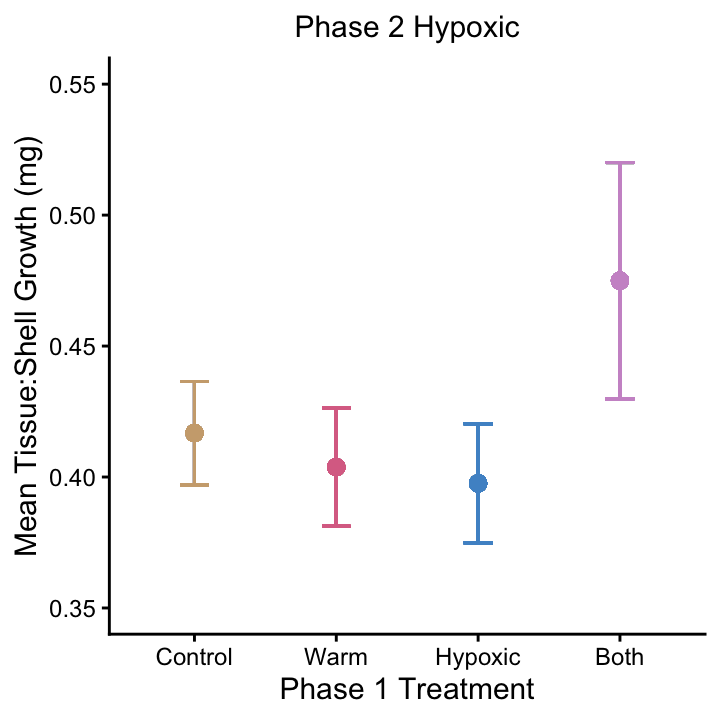

In [83]:
#phase 2 hypoxia plot
  summary_stats_t_s <- Growth_Data_forR_full %>%
  filter(Phase_2_treat == "Hyp") %>%
  group_by(Phase_1_treat, Phase_2_treat) %>%
  mutate(mean_growth = mean(Ratio_tissue_shell_mg, na.rm = TRUE),
    se_growth = std.error(Ratio_tissue_shell_mg, na.rm = TRUE))

summary_stats_t_s$Phase_1_treat <- factor(summary_stats_t_s$Phase_1_treat, levels = c("Cont", "Warm", "Hyp", "Both"))

ggplot(summary_stats_t_s, aes(x = Phase_1_treat, y = mean_growth, color = Phase_1_treat)) +
geom_point(size = 4) +
geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), width = 0.2) +
theme_classic(base_size = 18) +
guides(color = "none") +
scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3","Both" = "plum3")) +
  labs(
    title = "Phase 2 Hypoxic",
    x = "Phase 1 Treatment",
    y = "Mean Tissue:Shell Growth (mg)") +
scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
ylim(0.35, 0.55) +
theme(plot.title = element_text(size = 18, hjust = 0.5))

### In hypoxic conditions, early life exposure to both stressors increased relative tissue growth (compared to warm and hypoxic) (not significant, p = 0.096)

Exposure to both stressors in early life may have adaptively primed oysters to tolerate hypoxia later on.  
Double stressor increases tissue:shell growth compared to single stressors

In [ ]:
#Hyp Warm Hyp Ambient - Norm Warm Hyp Ambient          p = 0.0358
# Both  - Warm 
#Hyp Warm Hyp Ambient - Hyp Ambient Hyp Ambient        p = 0.0296
# Both  - Hyp 